In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
OCORRENCIAS = r'C:\Users\lucas.emoura\Documents\PastaLucas\aula01_UC2\aula02\03.BaseDPEvolucaoMensalCisp.csv'
DP = r'C:\Users\lucas.emoura\Documents\PastaLucas\aula01_UC2\aula02\08.DP.csv'

df_ocorrencias = pd.read_csv(
    OCORRENCIAS,
    sep=';',
    encoding='iso-8859-1'
)

df_DP = pd.read_csv(
    DP
)

df_DP.head(10)

,codDP,nome,endereco
0,1,001ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
1,4,004ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
2,5,005ª DP - Mem de Sá,"Avenida Gomes Freire, 320 - Centro, Rio de Jan..."
3,6,006ª DP - Cidade Nova,"Rua Professor Clementino Fraga, 77 - Centro, R..."
4,7,007ª DP - Santa Teresa,"Rua Francisco de Castro, 5 - Santa Teresa, Rio..."
5,9,009ª DP - Catete,"Rua Pedro Américo, 1 - Catete, Rio de Janeiro ..."
6,10,010ª DP - Botafogo,"Rua Bambina, 140 - Botafogo, Rio de Janeiro - ..."
7,11,011ª DP - Rocinha,"Rua Bertha Lutz, 80 - Gávea, Rio de Janeiro - ..."
8,12,012ª DP - Copacabana,"Rua Hilário de Gouveia, 102 - Copacabana, Rio ..."
9,13,013ª DP - Ipanema,"Avenida Nossa Senhora de Copacabana, 1260 - Co..."


In [12]:
df_merge = df_ocorrencias.merge(
    df_DP, # com quem juntar
    how='left', # como juntar (inner, left, outer)
    right_on='codDP', # coluna da tabela a direita (com quem juntar)
    left_on='cisp' # coluna da tabela a esquerda (quem chamou)
)
df_merge.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,codDP,nome,endereco
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,2,0,0,0,0,578,3,1.0,001ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,6,0,1,0,0,441,3,4.0,004ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,2,1,0,0,0,637,3,5.0,005ª DP - Mem de Sá,"Avenida Gomes Freire, 320 - Centro, Rio de Jan..."
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,2,1,0,0,0,473,3,6.0,006ª DP - Cidade Nova,"Rua Professor Clementino Fraga, 77 - Centro, R..."
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,1,3,0,0,0,147,3,7.0,007ª DP - Santa Teresa,"Rua Francisco de Castro, 5 - Santa Teresa, Rio..."


In [13]:
df_merge.columns

Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [14]:
df_roubo_banco = df_merge[[
    'cisp', 'nome', 'roubo_banco',
    'munic', 'regiao', 'ano'
]]

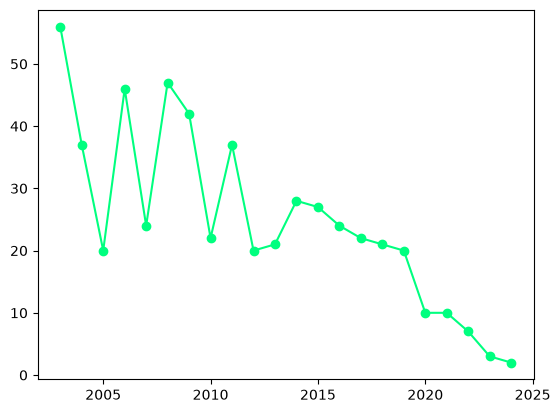

C:\Users\lucas.emoura\AppData\Local\Temp\ipykernel_19856\4211013208.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_roubo_banco_por_ano['roubo_banco'],


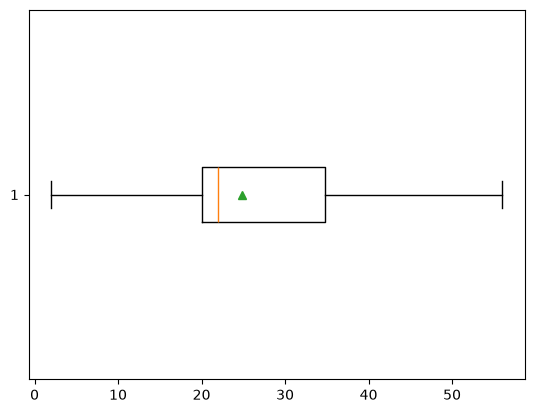

In [15]:
df_roubo_banco_por_ano = (
    df_roubo_banco.groupby('ano')['roubo_banco']
    .sum().reset_index()
)

# grafico de linha -> plot
plt.plot(df_roubo_banco_por_ano['ano'],
         df_roubo_banco_por_ano['roubo_banco'],
         marker='o', color='springgreen')
plt.show()

plt.boxplot(df_roubo_banco_por_ano['roubo_banco'],
            showfliers=True, # mostrar ou não outliers
            showmeans=True, # mostrar ou não a media 
            vert=False) # se esta na vertical ou horizontal
plt.show()


In [16]:
assimetria = df_roubo_banco_por_ano['roubo_banco'].skew()
curtose = df_roubo_banco_por_ano['roubo_banco'].kurtosis()

print(f'Assimetria: {assimetria:.4f}')
print(f'Curtose: {curtose:.4f}')

Assimetria: 0.4254
Curtose: -0.2634


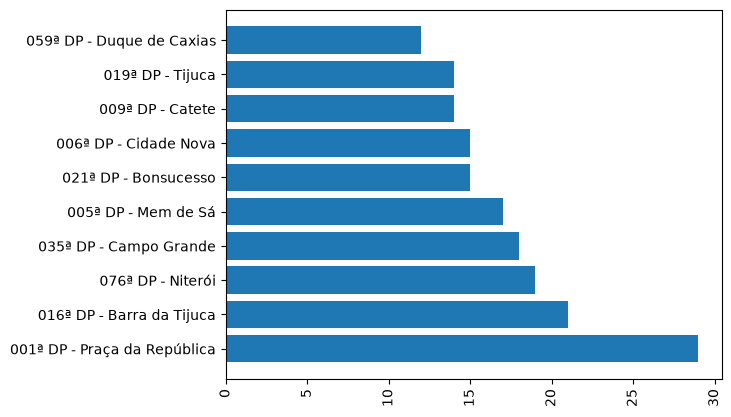

In [22]:
df_roubo_banco_por_dp = (
    df_roubo_banco.groupby('nome')['roubo_banco']
    .sum().reset_index()
    .sort_values(by='roubo_banco', ascending=False)
)
df_roubo_banco_por_dp = df_roubo_banco_por_dp.iloc[0:10]
plt.barh(df_roubo_banco_por_dp['nome'],
        df_roubo_banco_por_dp['roubo_banco'])
plt.xticks(rotation=90)
plt.show()

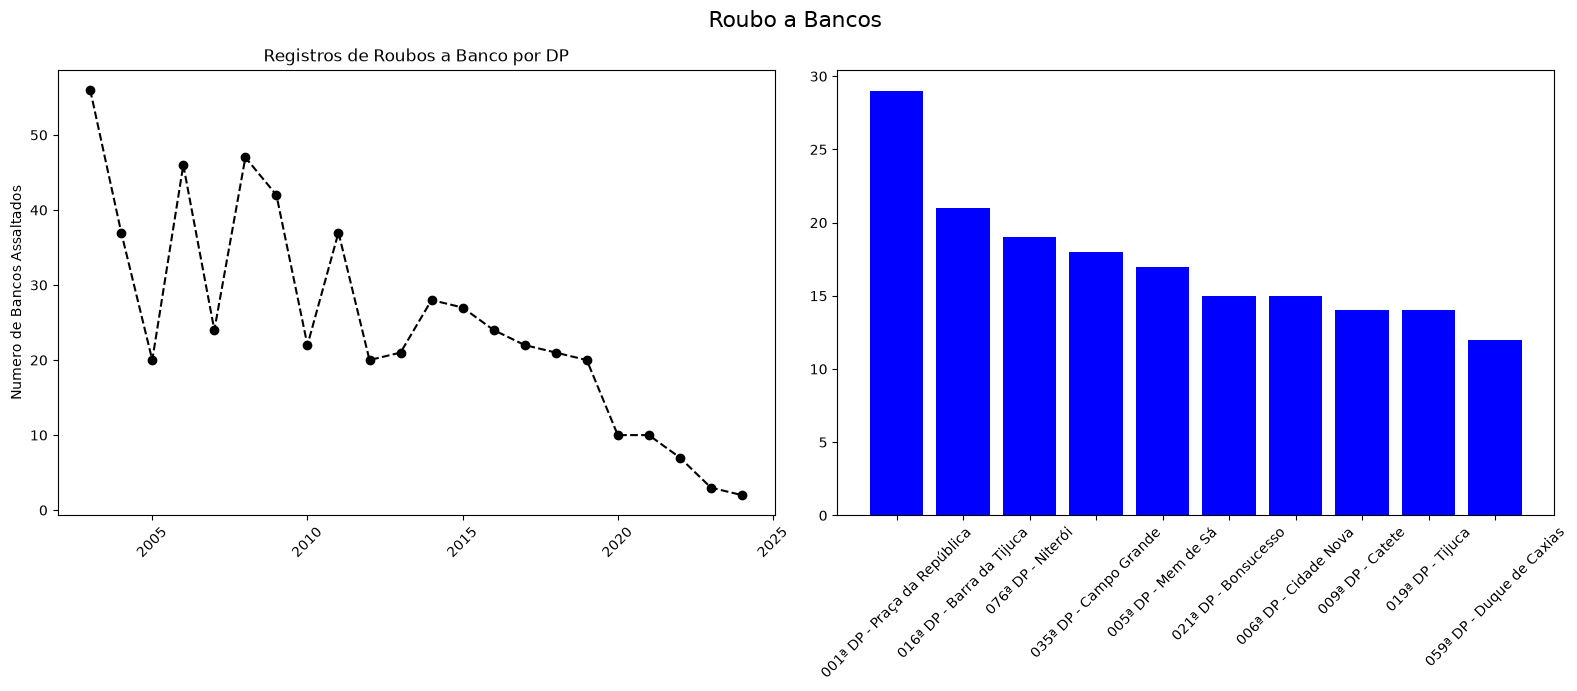

In [ ]:
# "painel" de graficos
# 1. criar uma area para os graficos -> (1, 2) -> 2 espaços
plt.subplots(1, 2, figsize=(16, 7))
# (numLinhas, numColunas, tamanhoImagem)
plt.suptitle('Roubo a Bancos', fontsize=16)
# titulo dos plots (da imagem)

#---------------------------
# subplot -> (x, y, z) -> x e y repetem valor dos subplots
# z -> posição do grafico no subplot
#---------------------------

# primeiro grafico
plt.subplot(1, 2, 1)
plt.plot(df_roubo_banco_por_ano['ano'],
         df_roubo_banco_por_ano['roubo_banco'],
         marker='o', color='black', linestyle='--')
plt.ylabel('Numero de Bancos Assaltados')
plt.title('Registros de Roubos a Banco por DP')
plt.xticks(rotation=45)

# segundo grafico
plt.subplot(1, 2, 2)
plt.bar(df_roubo_banco_por_dp['nome'],
        df_roubo_banco_por_dp['roubo_banco'],
        color='blue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# plt.subplot(2, 2, 4)
# plt.text('Média: {media:.2f}')
